(lecture06:homework)=
# Homework 6

+ Type your name and email in the "Student details" section below.
+ Develop the code and generate the figures you need to solve the problems using this notebook.
+ For the answers that require a mathematical proof or derivation you can either:
    
    - Type the answer using the built-in latex capabilities. In this case, simply export the notebook as a pdf and upload it on gradescope; or
    - You can print the notebook (after you are done with all the code), write your answers by hand, scan, turn your response to a single pdf, and upload on gradescope.

+ The total homework points are 100. Please note that the problems are not weighed equally.

```{note}
+ Please match all the pages corresponding to each of the questions when you submit on gradescope.
```

## Student details

+ **First Name:** Pranav
+ **Last Name:** Kuna
+ **Email:** pkuna@purdue.edu

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set(rc={"figure.dpi":100, 'savefig.dpi':300})
sns.set_context('notebook')
sns.set_style("ticks")
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('retina', 'svg')
import requests
import os
def download(url, local_filename=None):
    """
    Downloads the file in the ``url`` and saves it in the current working directory.
    """
    data = requests.get(url)
    if local_filename is None:
        local_filename = os.path.basename(url)
    with open(local_filename, 'wb') as fd:
        fd.write(data.content)

/tmp/ipykernel_4081/1846507495.py:8: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('retina', 'svg')


## Problem 1 - Loops and conditionals

Consider the following list:

In [1]:
data = [1, 4, 3, 10, 4, 3, 4, 4]

+ Write a loop that computes the average of the elements in the list and ``print`` the result using two significant digits.

In [3]:
# your code here
avg = sum(data)/len(data)
print(f"{avg:.2f}")

4.12


+ Write code that finds the number of times the element 4 occurs in the list. Hint: Use a loop and an if-statement.

In [4]:
# your code here
count = 0
for i in data:
    if i == 4:
        count += 1
print(count)

4


+ Write a Python function that takes a list as an argument and returns the number of times a given element (also passed as an argument to the function) appears in the list. Call that function ``find_number_of_occurences(a, elm)``. Make sure you follow best practices when writing the docstring of your function.

In [6]:
# your code here
def find_number_of_occurences(a, elm):
    """
    Finds the number of times a given element appears in a list.
    """
    count = 0
    for item in a:
        if item == elm:
            count += 1
    return count

In [7]:
# Try your code here:
help(find_number_of_occurences)

Help on function find_number_of_occurences in module __main__:

find_number_of_occurences(a, elm)
    Finds the number of times a given element appears in a list.



In [8]:
# Try your code here:
find_number_of_occurences(data, 4)

4

+ Write a Python function that takes a list as an argument and returns the number of elements that are greater than a given element (also passed as an argument to the function). Call that function ``find_number_of_elms_greater_than(a, elm)``. Make sure you follow best practices when writing the docstring of your function.

In [9]:
# your code here
def find_number_of_elms_greater_than(a, elm):
    """
    Finds the number of elements in a list that are greater than a given element.
    """
    count = 0
    for item in a:
        if item > elm:
            count += 1
    return count

In [10]:
# Try your code here:
help(find_number_of_elms_greater_than)


Help on function find_number_of_elms_greater_than in module __main__:

find_number_of_elms_greater_than(a, elm)
    Finds the number of elements in a list that are greater than a given element.



In [11]:
# Try your code here:
find_number_of_elms_greater_than(data, 3)


5

## Problem 2 - High-performance buildings revisited

In this problem we will continue analyzing the high-performance buildings dataset we introduced in {ref}`lecture03:homework:problem1` and with which we played in {ref}`lecture06:selecting-rows`.
Let me set you up by downloading and cleaning the data file:

In [13]:
!curl -O 'https://raw.githubusercontent.com/PurdueMechanicalEngineering/me-239-intro-to-data-science/master/data/temperature_raw.xlsx'
import pandas as pd
df = pd.read_excel('temperature_raw.xlsx')
df = df.dropna(axis=0)
df.date = pd.to_datetime(df['date'], format='%Y-%m-%d')
df.head()

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  277k  100  277k    0     0   847k      0 --:--:-- --:--:-- --:--:--  847k


,household,date,score,t_out,t_unit,hvac
0,a1,2018-01-07,100.0,4.283373,66.693229,246.473231
1,a10,2018-01-07,100.0,4.283373,66.356134,5.492116
2,a11,2018-01-07,58.0,4.283373,71.549132,402.094327
3,a12,2018-01-07,64.0,4.283373,73.429514,211.692244
4,a13,2018-01-07,100.0,4.283373,63.923937,0.850536


+ Plot the external temperature `t_out`

(array([17532., 17622., 17713., 17805., 17897., 17987., 18078., 18170.,
        18262., 18353.]),
 [Text(17532.0, 0, '2018-01'),
  Text(17622.0, 0, '2018-04'),
  Text(17713.0, 0, '2018-07'),
  Text(17805.0, 0, '2018-10'),
  Text(17897.0, 0, '2019-01'),
  Text(17987.0, 0, '2019-04'),
  Text(18078.0, 0, '2019-07'),
  Text(18170.0, 0, '2019-10'),
  Text(18262.0, 0, '2020-01'),
  Text(18353.0, 0, '2020-04')])

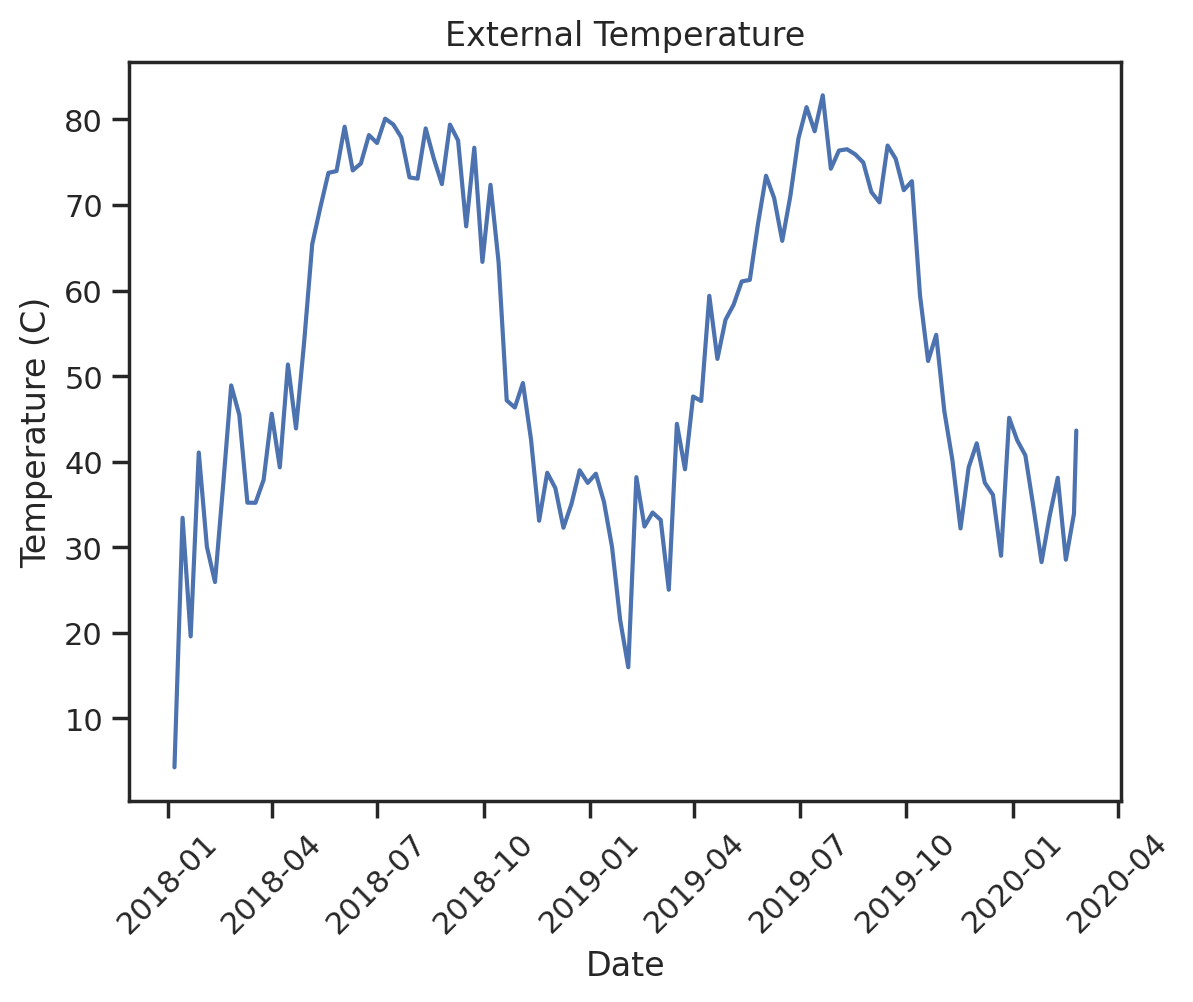

In [24]:
# Your code here
plt.plot(df.date, df.t_out)
plt.xlabel("Date")
plt.ylabel("Temperature (C)")
plt.title("External Temperature")
plt.xticks(rotation=45)

+ Extract the data pertaining to household `a5`.
Put the result in a new dataframe called `df_a5`.

In [20]:
df_a5 = df[df.household == 'a5']
df_a5.head()

,household,date,score,t_out,t_unit,hvac
11,a5,2018-01-07,64.0,4.283373,74.854456,286.011150
61,a5,2018-01-14,78.0,33.444172,74.786855,137.786711
111,a5,2018-01-21,67.0,19.584102,75.463740,229.760337
161,a5,2018-01-28,74.0,41.076513,75.382341,79.433718
211,a5,2018-02-04,64.0,30.065774,75.676811,118.032515


+ For household `a5`, plot `t_unit` as a function of date.

(array([17532., 17622., 17713., 17805., 17897., 17987., 18078., 18170.,
        18262., 18353.]),
 [Text(17532.0, 0, '2018-01'),
  Text(17622.0, 0, '2018-04'),
  Text(17713.0, 0, '2018-07'),
  Text(17805.0, 0, '2018-10'),
  Text(17897.0, 0, '2019-01'),
  Text(17987.0, 0, '2019-04'),
  Text(18078.0, 0, '2019-07'),
  Text(18170.0, 0, '2019-10'),
  Text(18262.0, 0, '2020-01'),
  Text(18353.0, 0, '2020-04')])

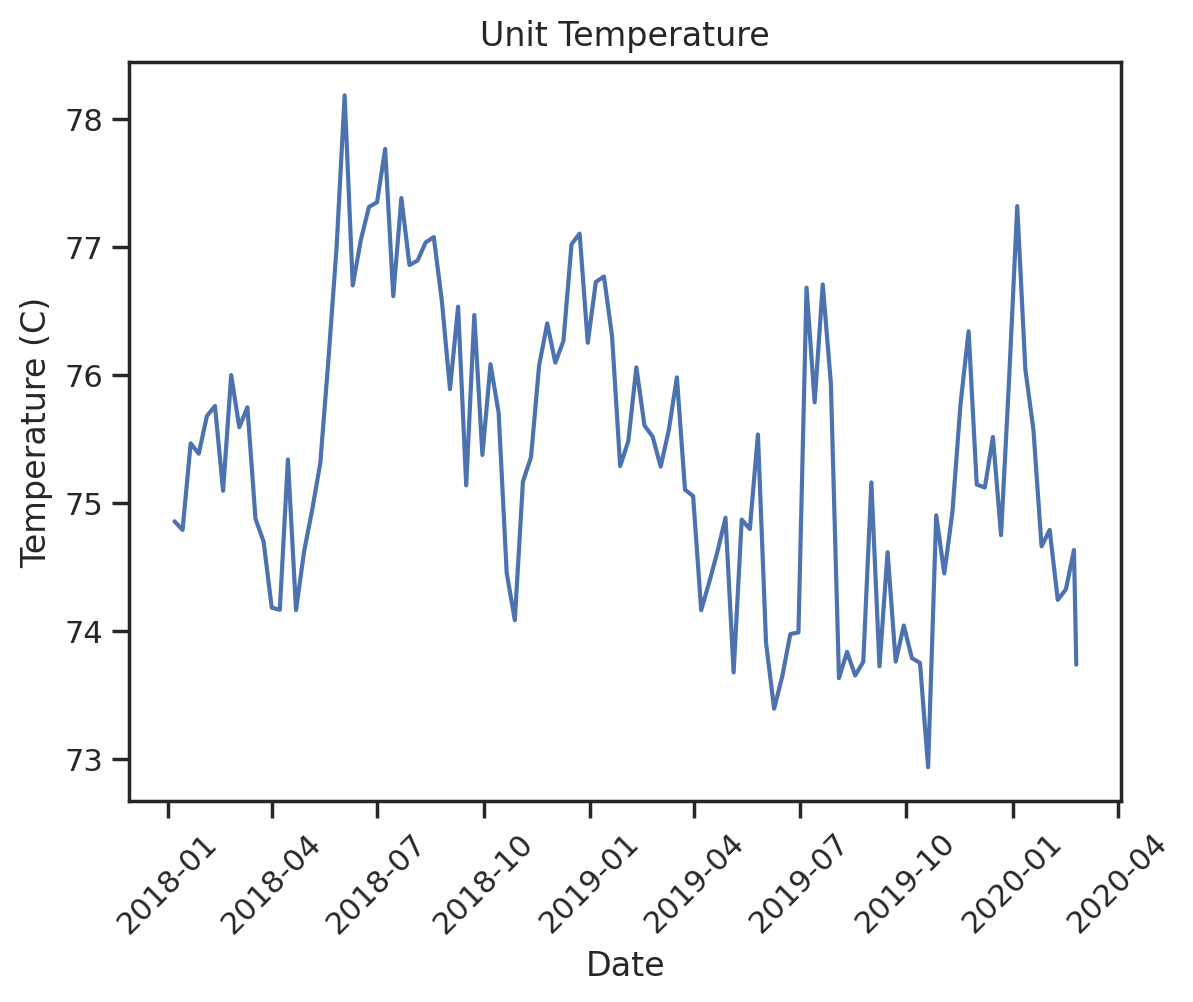

In [23]:
# Your code here
plt.plot(df_a5.date, df_a5.t_unit)
plt.xlabel("Date")
plt.ylabel("Temperature (C°)")
plt.title("Unit Temperature")
plt.xticks(rotation=45)


+ In a single figure, plot `date` vs `t_unit` for households `a5` and `a11`.

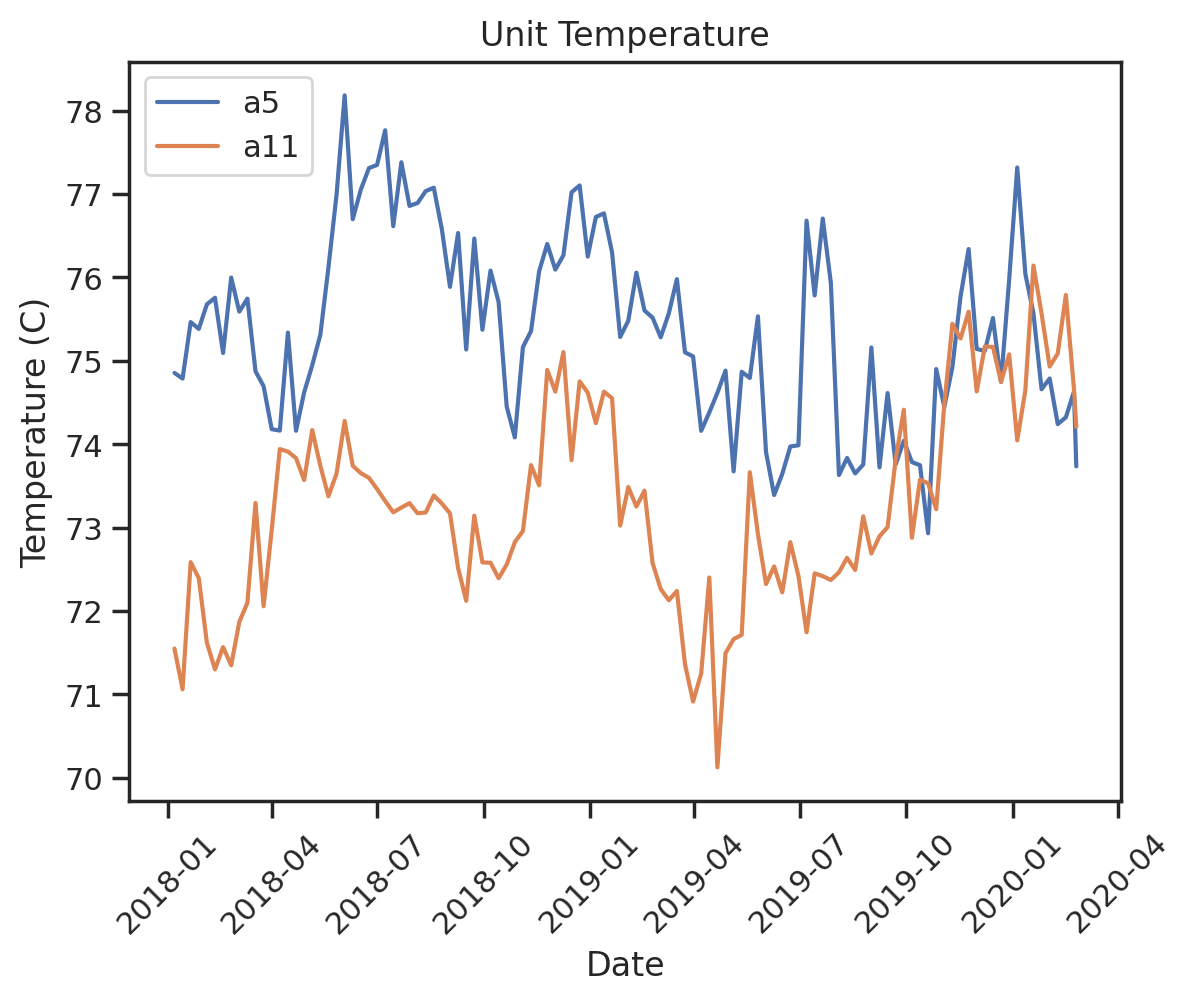

In [26]:
# Your code here
df_a11 = df[df.household == 'a11']
plt.plot(df_a5.date, df_a5.t_unit, label='a5')
plt.plot(df_a11.date, df_a11.t_unit, label='a11')
plt.xlabel("Date")
plt.ylabel("Temperature (C°)")
plt.title("Unit Temperature")
plt.xticks(rotation=45)
plt.legend()


+ In the same figure, plot the `t_out` and `t_unit` scatter plots for both households `a5` and `a11`.

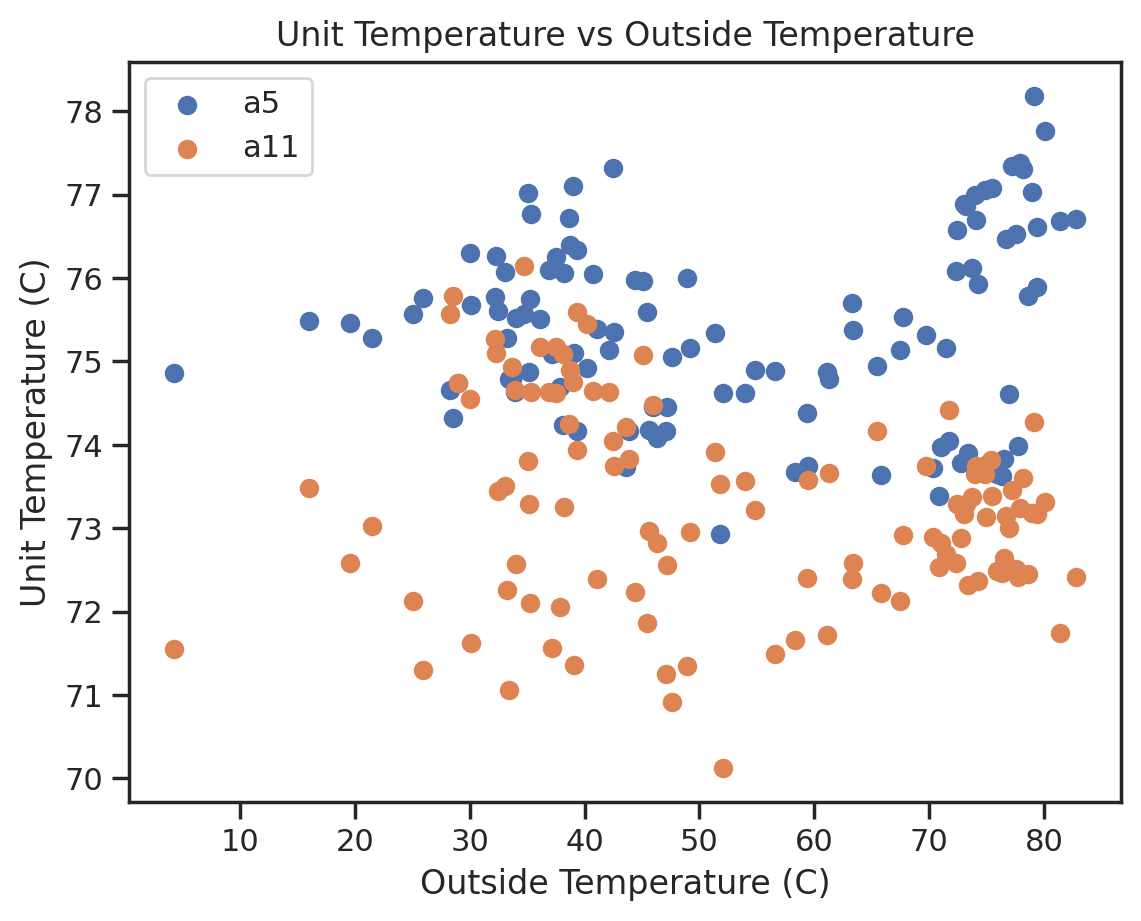

In [28]:
# Your code here
plt.scatter(df_a5.t_out, df_a5.t_unit, label='a5')
plt.scatter(df_a11.t_out, df_a11.t_unit, label='a11')
plt.xlabel("Outside Temperature (C)")
plt.ylabel("Unit Temperature (C)")
plt.title("Unit Temperature vs Outside Temperature")
plt.legend()

+ In the same figure, plot the `t_out` and `hvac` scatter plots for both households `a5` and `a11`.

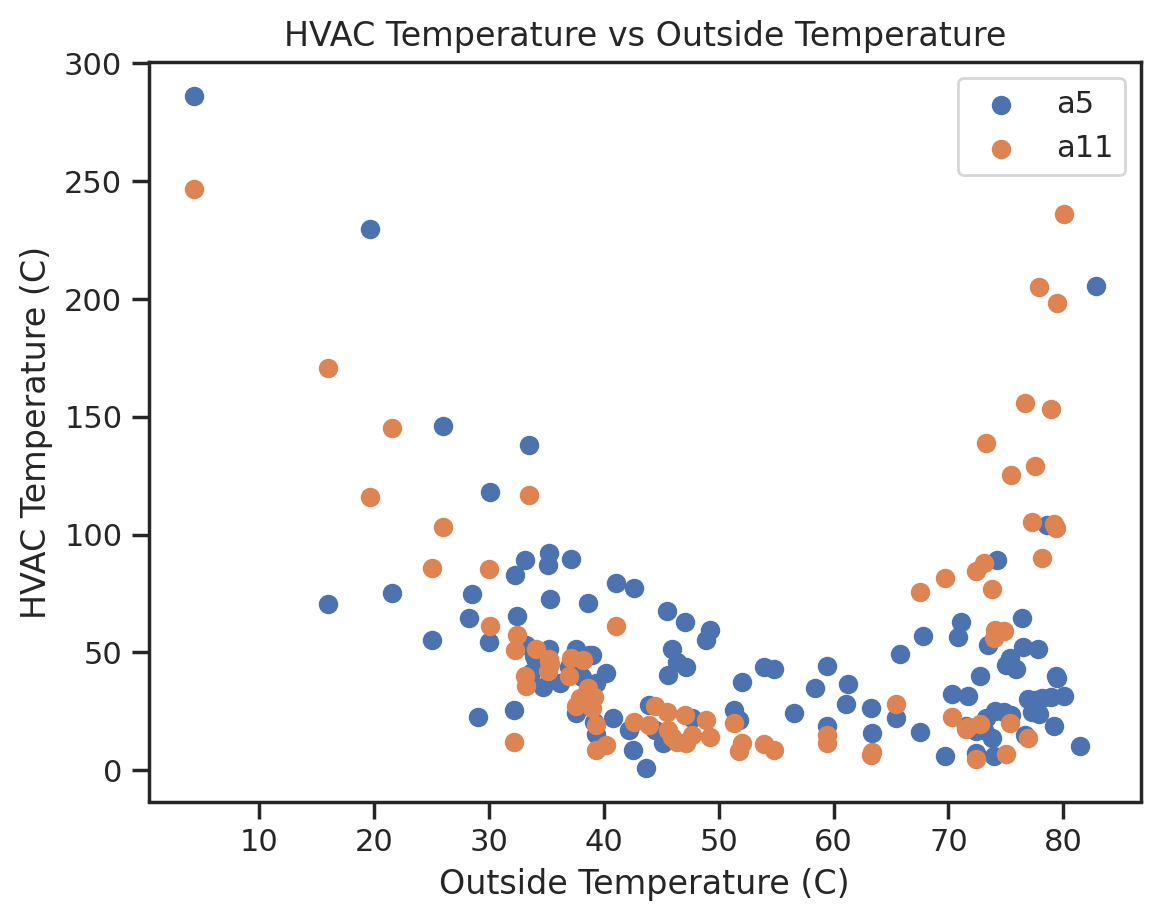

In [29]:
# Your code here
df_a5 = df[df.household == 'a5']
df_a11 = df[df.household == 'a1']
plt.scatter(df_a5.t_out, df_a5.hvac, label='a5')
plt.scatter(df_a11.t_out, df_a11.hvac, label='a11')
plt.xlabel("Outside Temperature (C°)")
plt.ylabel("HVAC Temperature (C°)")
plt.title("HVAC Temperature vs Outside Temperature")
plt.legend()

+ In the same figure, plot the histogram of `t_unit` for households `a5` and `a11`.
Which household prefers cooler temperatures?
Hint: To make the histogram more appealing use the keywords ``density=True, alpha=0.25``.

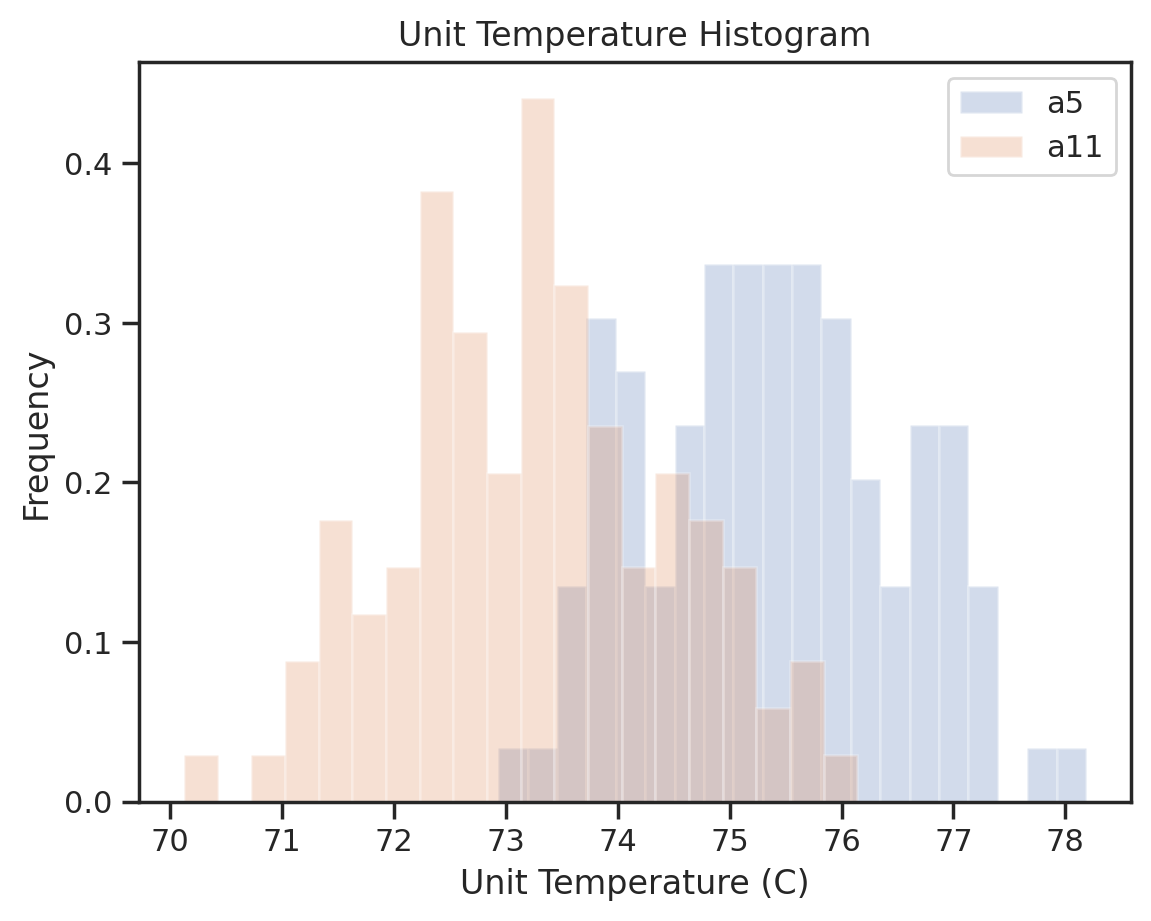

In [30]:
# Your code here
df_a5 = df[df.household == 'a5']
df_a11 = df[df.household == 'a11']
plt.hist(df_a5.t_unit, bins=20, density=True, alpha=0.25, label='a5')
plt.hist(df_a11.t_unit, bins=20, density=True, alpha=0.25, label='a11')
plt.xlabel("Unit Temperature (C°)")
plt.ylabel("Frequency")
plt.title("Unit Temperature Histogram")
plt.legend()

From the graph we can see that household A11 prefers colder temps since the bins for that household seem to have a lower average. We can also look at the line chart a couple pages up and see that the line for household A11 is generally lower than the one for household A5 meaning that usually house A11 is colder.

+ In the same figure, plot the histogram of `hvac` for households `a5` and `a11`.
Which household is more energy efficient (if any) and why?

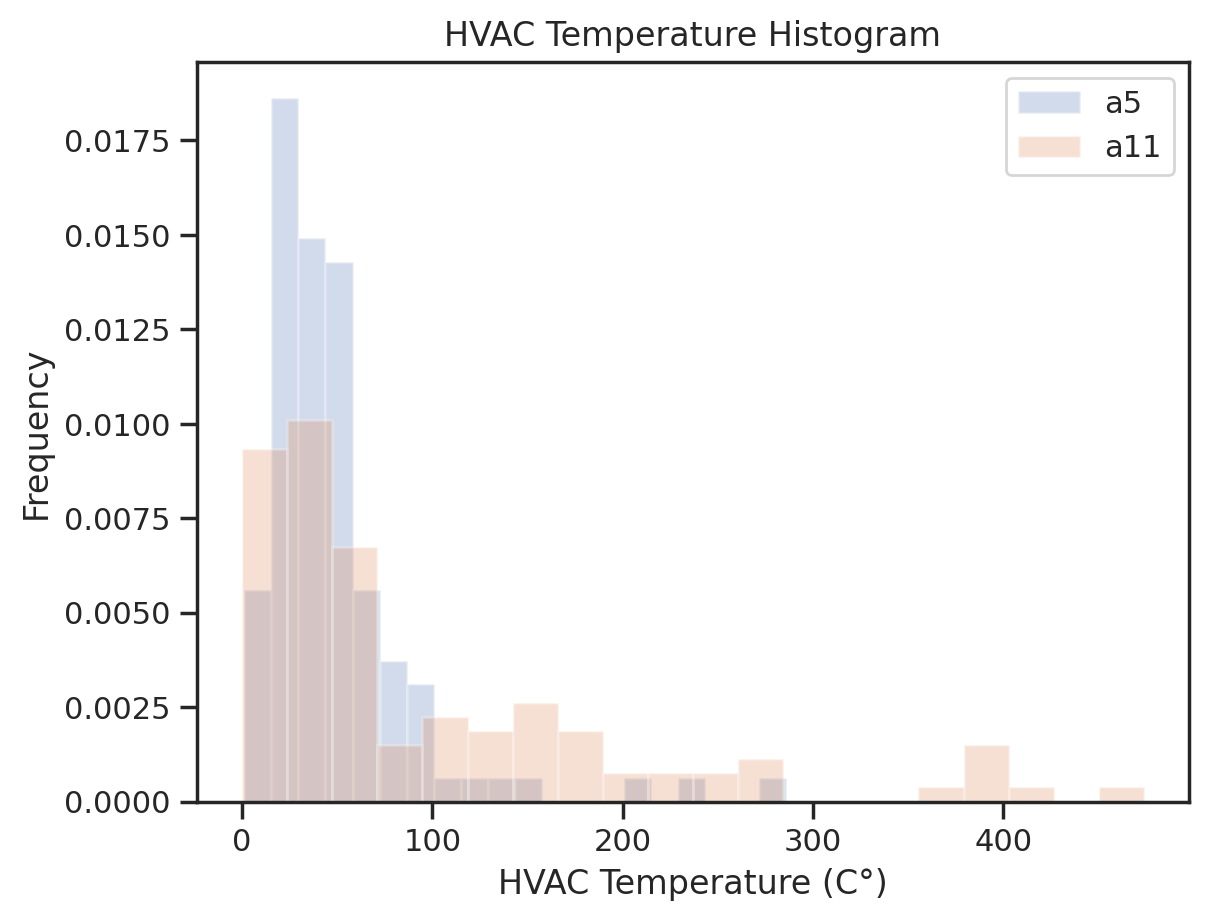

In [31]:
# Your code here
df_a5 = df[df.household == 'a5']
df_a11 = df[df.household == 'a11']
plt.hist(df_a5.hvac, bins=20, density=True, alpha=0.25, label='a5')
plt.hist(df_a11.hvac, bins=20, density=True, alpha=0.25, label='a11')
plt.xlabel("HVAC Temperature (C°)")
plt.ylabel("Frequency")
plt.title("HVAC Temperature Histogram")
plt.legend()


Household A5 is more efficent since they have their HVAC system running less and therefore at a lower temperature. We can look at the chart above and see that the max temperature for household a5 is around 300C° while the max for a11 is around 400C°. We can also see that the average for a11 seems to be around 100 C° while the average for a5 seems to be around 50C°.

+ Repeat the analysis above for households `b17` and `c40`. Which household prefers cooler temperatures and which one is more energy efficient?

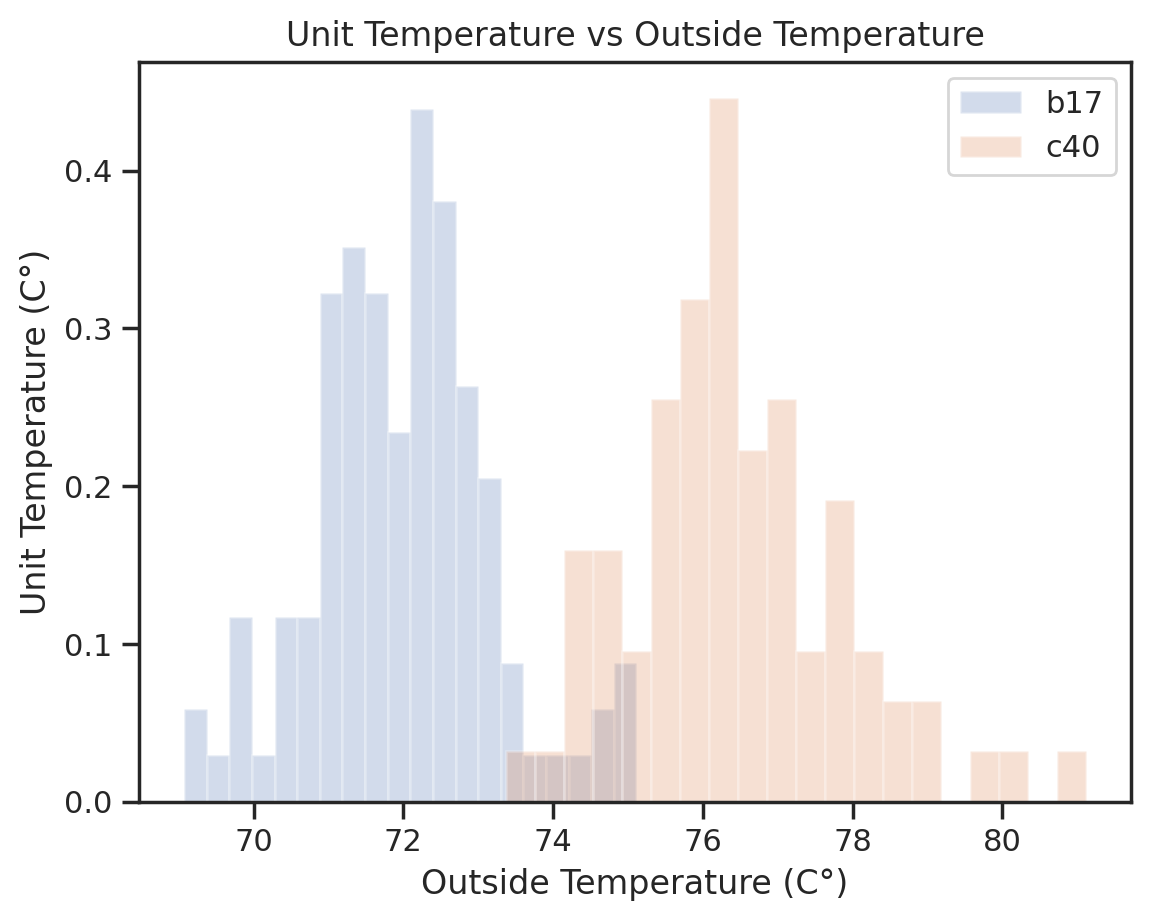

In [34]:
# your code here
df_b17 = df[df.household == 'b17']
df_c40 = df[df.household == 'c40']
plt.hist(df_b17.t_unit, bins=20, density=True, alpha=0.25, label='b17')
plt.hist(df_c40.t_unit, bins=20, density=True, alpha=0.25, label='c40')
plt.xlabel("Outside Temperature (C°)")
plt.ylabel("Unit Temperature (C°)")
plt.title("Unit Temperature vs Outside Temperature")
plt.legend()

*Your answer and explanation here. Use as many code and markdown blocks as you want.*

Household b17 seems to be

Run the following code to convert the notebook to a pdf. Verify that the file path to the notebook is correct.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!apt-get install inkscape texlive texlive-xetex texlive-latex-extra pandoc --quiet
!pip install pypandoc --quiet
!jupyter nbconvert --to PDF '/content/drive/MyDrive/Colab Notebooks/Copy of homework_06.ipynb'